<a href="https://colab.research.google.com/github/Ashwin-2408/Tensor_Flow_Learning/blob/main/notebooks/MulitClass_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MultiClass CNN

In [1]:
! wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

--2025-06-18 09:03:13--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.2.207, 142.250.141.207, 74.125.137.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.2.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip.2’

10_food_classes_all 100%[===================>] 495.13M   296MB/s    in 1.7s    

2025-06-18 09:03:15 (296 MB/s) - ‘10_food_classes_all_data.zip.2’ saved [519183241/519183241]



In [2]:
import zipfile
zip_ref=zipfile.ZipFile("10_food_classes_all_data.zip")
zip_ref.extractall()
zip_ref.close()

In [3]:
import os

for dirpath,dirnames,filenames in os.walk("/content/10_food_classes_all_data"):
  print(f"there are {len(dirnames)} directories and {len(filenames)} in '{dirpath}'." )

there are 2 directories and 0 in '/content/10_food_classes_all_data'.
there are 10 directories and 0 in '/content/10_food_classes_all_data/train'.
there are 0 directories and 750 in '/content/10_food_classes_all_data/train/steak'.
there are 0 directories and 750 in '/content/10_food_classes_all_data/train/grilled_salmon'.
there are 0 directories and 750 in '/content/10_food_classes_all_data/train/ice_cream'.
there are 0 directories and 750 in '/content/10_food_classes_all_data/train/pizza'.
there are 0 directories and 750 in '/content/10_food_classes_all_data/train/chicken_curry'.
there are 0 directories and 750 in '/content/10_food_classes_all_data/train/sushi'.
there are 0 directories and 750 in '/content/10_food_classes_all_data/train/chicken_wings'.
there are 0 directories and 750 in '/content/10_food_classes_all_data/train/fried_rice'.
there are 0 directories and 750 in '/content/10_food_classes_all_data/train/ramen'.
there are 0 directories and 750 in '/content/10_food_classes_al

(512, 512, 3)

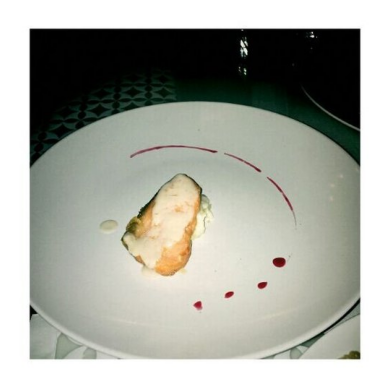

In [4]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
image=mpimg.imread("/content/10_food_classes_all_data/train/grilled_salmon/1002334.jpg")
plt.imshow(image)
plt.axis("off")
image.shape


In [5]:
class_names=["ice_cream","ramen","fried_rice","hamburger","chicken_wings","sushi","chicken_curry","pizza","grilled_salmon","steak"]

## Creating a function to view the different classes and their images along with analyzing their shapes.

In [6]:
import random
def view_image(target,class_names):
  random_class=random.randint(0,len(class_names)-1)
  target_directory=target+"/"+class_names[random_class]
  file_names=os.listdir(target_directory)
  random_image=random.randint(0,len(file_names)-1)
  target_image=target_directory+"/"+file_names[random_image]
  image=mpimg.imread(target_image)
  print(image.shape)
  plt.imshow(image)
  plt.axis(False)
  plt.title(class_names[random_class])

(512, 307, 3)


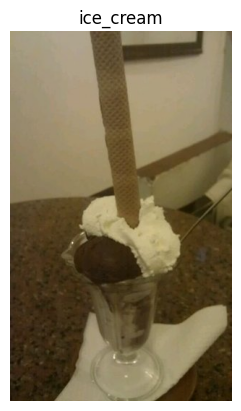

In [7]:
view_image("/content/10_food_classes_all_data/train",class_names)

##Preprocessing the Data


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
train_data_gen=ImageDataGenerator(rescale=1/255.)
test_data_gen=ImageDataGenerator(rescale=1/255.)

#loading data from directories and converting them in to batches

Train_Data=train_data_gen.flow_from_directory("/content/10_food_classes_all_data/train",target_size=(224,224),class_mode="categorical",batch_size=32)
Test_Data=test_data_gen.flow_from_directory("/content/10_food_classes_all_data/test",target_size=(224,224),class_mode="categorical",batch_size=32)

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


## Creating a MultiClass CNN  Model

In [10]:
import tensorflow as tf
import numpy as np
import random


random.seed(42)
tf.random.set_seed(42)
np.random.seed(42)


Model_v1=tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=10,kernel_size=3,input_shape=(224,224,3),padding='valid',activation="relu"),
    tf.keras.layers.Conv2D(10,3,activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(10,3,activation="relu"),
    tf.keras.layers.Conv2D(10,3,activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10,activation="softmax")
    ])

Model_v1.compile(loss=tf.keras.losses.CategoricalCrossentropy(),optimizer=tf.keras.optimizers.Adam(),metrics=["accuracy"])

history_1=Model_v1.fit(Train_Data,epochs=5,steps_per_epoch=len(Train_Data),validation_data=Test_Data,validation_steps=len(Test_Data))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


235/235 ━━━━━━━━━━━━━━━━━━━━ 36s 132ms/step - accuracy: 0.1615 - loss: 2.2287 - val_accuracy: 0.3392 - val_loss: 1.8990
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 32s 110ms/step - accuracy: 0.3811 - loss: 1.8121 - val_accuracy: 0.3676 - val_loss: 1.8322
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 31s 131ms/step - accuracy: 0.5819 - loss: 1.2944 - val_accuracy: 0.3432 - val_loss: 2.0703
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 107ms/step - accuracy: 0.8151 - loss: 0.6000 - val_accuracy: 0.3136 - val_loss: 2.8243
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 107ms/step - accuracy: 0.9552 - loss: 0.1805 - val_accuracy: 0.2984 - val_loss: 3.7753


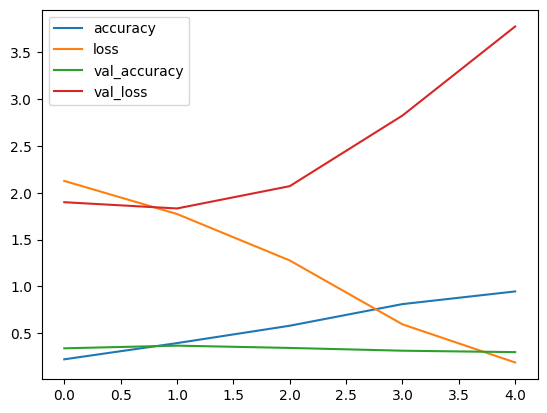

In [11]:
import pandas as pd
pd.DataFrame(history_1.history).plot()
plt.show()

Our model is overfitting

## Adjusting Model HyperParameters to improve the Baseline Model

In [12]:
import tensorflow as tf
import numpy as np
import random


random.seed(42)
tf.random.set_seed(42)
np.random.seed(42)


Model_v2=tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=10,kernel_size=3,input_shape=(224,224,3),padding='valid',activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(10,3,activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10,activation="softmax")
    ])

Model_v2.compile(loss=tf.keras.losses.CategoricalCrossentropy(),optimizer=tf.keras.optimizers.Adam(),metrics=["accuracy"])

history_2=Model_v2.fit(Train_Data,epochs=5,steps_per_epoch=len(Train_Data),validation_data=Test_Data,validation_steps=len(Test_Data))

Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 117ms/step - accuracy: 0.1758 - loss: 2.3397 - val_accuracy: 0.3172 - val_loss: 1.9686
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 36s 103ms/step - accuracy: 0.3854 - loss: 1.8237 - val_accuracy: 0.3244 - val_loss: 1.9426
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 113ms/step - accuracy: 0.5355 - loss: 1.4454 - val_accuracy: 0.3268 - val_loss: 1.9812
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 48s 143ms/step - accuracy: 0.7130 - loss: 0.9651 - val_accuracy: 0.2996 - val_loss: 2.2617
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 32s 107ms/step - accuracy: 0.8473 - loss: 0.5741 - val_accuracy: 0.2864 - val_loss: 2.7321


In [13]:
Model_v1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       280,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 851,762 (3.25 MB)

 Trainable params: 283,920 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 567,842 (2.17 MB)

In [14]:
Model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 29160)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │       291,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 878,402 (3.35 MB)

 Trainable params: 292,800 (1.12 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 585,602 (2.23 MB)

Reducing the number of layers has decreased the accuracy of our model . Lets try data augmentation.

In [15]:
Augmented_Data_Generator=ImageDataGenerator(rescale=1/255.,width_shift_range=.3,height_shift_range=.3,shear_range=.2,zoom_range=.2,horizontal_flip=True)
Augmented_Data=Augmented_Data_Generator.flow_from_directory("/content/10_food_classes_all_data/train",batch_size=32,target_size=(224,224),class_mode="categorical")

Found 7500 images belonging to 10 classes.


Fitting our second model with the augmented data

In [17]:
Model_V3=tf.keras.models.clone_model(Model_v2)
Model_V3.compile(loss=tf.keras.losses.CategoricalCrossentropy(),optimizer=tf.keras.optimizers.Adam(),metrics=["accuracy"])
history_3=Model_V3.fit(Augmented_Data,epochs=5,steps_per_epoch=len(Augmented_Data),validation_data=Test_Data,validation_steps=len(Test_Data))

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 101s 421ms/step - accuracy: 0.1403 - loss: 2.4539 - val_accuracy: 0.2392 - val_loss: 2.1303
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 99s 423ms/step - accuracy: 0.2005 - loss: 2.1811 - val_accuracy: 0.2828 - val_loss: 2.0300
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 140s 413ms/step - accuracy: 0.2503 - loss: 2.1128 - val_accuracy: 0.3012 - val_loss: 1.9822
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 102s 433ms/step - accuracy: 0.2548 - loss: 2.1026 - val_accuracy: 0.3156 - val_loss: 1.9372
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 137s 411ms/step - accuracy: 0.2744 - loss: 2.0664 - val_accuracy: 0.3108 - val_loss: 1.9374


WE can see that our model has performed much better than the previous models.

In [18]:
! wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/images/03-sushi.jpeg

--2025-06-18 09:19:29--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/images/03-sushi.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1725178 (1.6M) [image/jpeg]
Saving to: ‘03-sushi.jpeg’

03-sushi.jpeg       100%[===================>]   1.64M  --.-KB/s    in 0.04s   

2025-06-18 09:19:29 (41.6 MB/s) - ‘03-sushi.jpeg’ saved [1725178/1725178]



In [73]:
def prediction(model,image_url,class_names):
  image=tf.io.read_file(image_url) # reads the image file in binary
  image=tf.image.decode_image(image) # converts the image into tensor[height,width,channels]
  image=tf.image.resize(image,[224,224]) # resizing the image to work for our model

  ypred=model.predict(tf.expand_dims(image,axis=0))
  print(ypred[0])
  class_name=tf.argmax(ypred[0])
  print(tf.cast(tf.argmax(ypred),dtype=tf.int32).numpy())
  image=mpimg.imread(image_url)
  plt.imshow(image)
  plt.title(f"The predicted class is {class_names[class_name]}")
  plt.axis(False)




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 4.3534787e-20 0.0000000e+00 0.0000000e+00 1.0000000e+00]
[0 0 0 0 0 0 0 0 0 0]


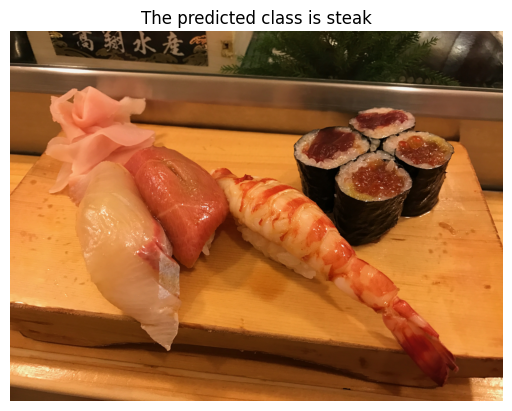

In [74]:


prediction(Model_V3,"/content/03-sushi.jpeg",class_names)